# Cours NLP - Prétraitement et Analyse de Texte
## Corpus: Livres de Lewis Carroll

## Installation et Imports

In [ ]:
import requests
import re
import nltk
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk import pos_tag, ne_chunk, word_tokenize
from nltk.tree import Tree
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

# Télécharger les ressources NLTK nécessaires
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('maxent_ne_chunker', quiet=True)
nltk.download('words', quiet=True)

print("Imports réussis!")

Imports réussis!


## PRÉTRAITEMENT DU TEXTE

### 1. Charger les textes et nettoyer les non-mots

In [ ]:
def load_texts(urls):
    """
    Charge les textes à partir d'une liste d'URL, nettoie les non-mots
    et retourne un corpus de textes nettoyés.
    """
    corpus = []

    for url in urls:
        try:
            response = requests.get(url)
            text = response.text
            # Nettoyer les non-mots à l'aide d'expressions régulières
            text = re.sub(r'[^a-zA-Z\s\n]', '', text)
            corpus.append(text)
            print(f"Texte chargé avec succès de {url}")
        except Exception as e:
            print(f"Erreur lors du chargement de {url}: {e}")

    return corpus

# URLs des livres
urls = [
    'https://www.gutenberg.org/cache/epub/11/pg11.txt',  # Alice's Adventures in Wonderland
    'https://www.gutenberg.org/cache/epub/12/pg12.txt',  # Through the Looking Glass
    'https://www.gutenberg.org/cache/epub/29042/pg29042.txt'  # A Tangled Tale
]

corpus_raw = load_texts(urls)

Texte chargé avec succès de https://www.gutenberg.org/cache/epub/11/pg11.txt
Texte chargé avec succès de https://www.gutenberg.org/cache/epub/12/pg12.txt
Texte chargé avec succès de https://www.gutenberg.org/cache/epub/29042/pg29042.txt


### 2. Afficher les 200 premiers caractères et retirer les parties non pertinentes

In [ ]:
titles = [
    "Les aventures d'Alice au pays des merveilles",
    "À TRAVERS LE MIROIR",
    "Un conte enchevêtré"
]

print("AVANT nettoyage:")
print("="*80)
for i, text in enumerate(corpus_raw):
    print(f"\n{titles[i]}:")
    print(text[:200])
    print()

AVANT nettoyage:

Les aventures d'Alice au pays des merveilles:
The Project Gutenberg eBook of Alices Adventures in Wonderland
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no


À TRAVERS LE MIROIR:
The Project Gutenberg eBook of Through the LookingGlass
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restri


Un conte enchevêtré:
The Project Gutenberg eBook of A Tangled Tale
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
wh



In [ ]:
def clean_gutenberg_text(text):
    """
    Retire les en-têtes et pieds de page de Project Gutenberg
    en utilisant les marqueurs 'COMMENCER' et 'FIN'
    """
    # Chercher le début du texte
    start_idx = text.upper().find('START')
    end_idx = text.upper().find('END')

    if start_idx != -1 and end_idx != -1:
        text = text[start_idx + 5:end_idx]
    elif start_idx != -1:
        text = text[start_idx + 5:]

    return text.strip()

corpus_cleaned = [clean_gutenberg_text(text) for text in corpus_raw]

print("APRÈS nettoyage:")
print("="*80)
for i, text in enumerate(corpus_cleaned):
    print(f"\n{titles[i]}:")
    print(text[:200])
    print(f"Longueur: {len(text)} caractères")

APRÈS nettoyage:

Les aventures d'Alice au pays des merveilles:
OF THE PROJECT GUTENBERG EBOOK ALICES ADVENTURES IN WONDERLAND 

Illustration




Alices Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 

Contents

 CHAPTER 
Longueur: 333 caractères

À TRAVERS LE MIROIR:
OF THE PROJECT GUTENBERG EBOOK THROUGH THE LOOKINGGLASS 

Illustration




THROUGH THE LOOKINGGLASS

And What Alice Found There

By Lewis Carroll

The Millennium Fulcrum Edition 




Longueur: 4959 caractères

Un conte enchevêtré:
OF THE PROJECT GUTENBERG EBOOK A TANGLED TALE 




Produced by Chris Curnow Carla Foust Lindy Walsh and the
Online Distributed Proofreading Team at httpswwwpgdpnet
Music transcribed by Linda Ca
Longueur: 353 caractères


### 3. Tokeniser le texte

In [ ]:
import nltk
nltk.download('punkt_tab', quiet=True)

# Tokeniser chaque texte
tokens_by_book = []

for i, text in enumerate(corpus_cleaned):
    tokens = word_tokenize(text.lower())
    tokens_by_book.append(tokens)
    print(f"\n{titles[i]}:")
    print(f"Nombre de tokens: {len(tokens)}")
    print(f"Les 150 premiers tokens:")
    print(tokens[:150])


Les aventures d'Alice au pays des merveilles:
Nombre de tokens: 46
Les 150 premiers tokens:
['of', 'the', 'project', 'gutenberg', 'ebook', 'alices', 'adventures', 'in', 'wonderland', 'illustration', 'alices', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'i', 'down', 'the', 'rabbithole', 'chapter', 'ii', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', 'a', 'caucusrace', 'and', 'a', 'long', 'tale', 'chapter', 'iv', 'the', 'rabbit', 's']

À TRAVERS LE MIROIR:
Nombre de tokens: 828
Les 150 premiers tokens:
['of', 'the', 'project', 'gutenberg', 'ebook', 'through', 'the', 'lookingglass', 'illustration', 'through', 'the', 'lookingglass', 'and', 'what', 'alice', 'found', 'there', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'dramatis', 'person', 'as', 'arranged', 'before', 'commencement', 'of', 'game', 'white', 'red', 'pieces', 'pawns', 'pawns', 'pieces', 'tweedledee', 'daisy', 'daisy', 'h

### 4. Supprimer les mots vides (stopwords)

In [ ]:
stop_words = set(stopwords.words('english'))

# Mots à chercher
words_to_check = ['i', 'me', 'my', 'myself', 'we', 'our', 'us', 'ourselves']

print("Mots d'arrêt anglais à vérifier:")
for word in words_to_check:
    is_stopword = word in stop_words
    print(f"  '{word}': {is_stopword}")

# Supprimer les stopwords
tokens_no_stopwords = []

for i, tokens in enumerate(tokens_by_book):
    filtered_tokens = [token for token in tokens if token not in stop_words and len(token) > 1]
    tokens_no_stopwords.append(filtered_tokens)

    print(f"\n{titles[i]}:")
    print(f"Tokens avant suppression des stopwords: {len(tokens)}")
    print(f"Tokens après suppression des stopwords: {len(filtered_tokens)}")
    print(f"Stopwords supprimés: {len(tokens) - len(filtered_tokens)}")

    # Vérifier la suppression
    for word in words_to_check:
        count_before = tokens.count(word)
        count_after = filtered_tokens.count(word)
        print(f"  Compte '{word}': avant={count_before}, après={count_after}")

Mots d'arrêt anglais à vérifier:
  'i': True
  'me': True
  'my': True
  'myself': True
  'we': True
  'our': True
  'us': False
  'ourselves': True

Les aventures d'Alice au pays des merveilles:
Tokens avant suppression des stopwords: 46
Tokens après suppression des stopwords: 30
Stopwords supprimés: 16
  Compte 'i': avant=1, après=0
  Compte 'me': avant=0, après=0
  Compte 'my': avant=0, après=0
  Compte 'myself': avant=0, après=0
  Compte 'we': avant=0, après=0
  Compte 'our': avant=0, après=0
  Compte 'us': avant=0, après=0
  Compte 'ourselves': avant=0, après=0

À TRAVERS LE MIROIR:
Tokens avant suppression des stopwords: 828
Tokens après suppression des stopwords: 476
Stopwords supprimés: 352
  Compte 'i': avant=5, après=0
  Compte 'me': avant=1, après=0
  Compte 'my': avant=2, après=0
  Compte 'myself': avant=0, après=0
  Compte 'we': avant=1, après=0
  Compte 'our': avant=3, après=0
  Compte 'us': avant=0, après=0
  Compte 'ourselves': avant=0, après=0

Un conte enchevêtré:
Tok

### 5. Stemming avec PorterStemmer

In [ ]:
porter = PorterStemmer()

tokens_stemmed = []

for i, tokens in enumerate(tokens_no_stopwords):
    stemmed = [porter.stem(token) for token in tokens]
    tokens_stemmed.append(stemmed)

    print(f"\n{titles[i]}:")
    print(f"Les 50 premiers tokens stemmed:")
    print(stemmed[:50])


Les aventures d'Alice au pays des merveilles:
Les 50 premiers tokens stemmed:
['project', 'gutenberg', 'ebook', 'alic', 'adventur', 'wonderland', 'illustr', 'alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'content', 'chapter', 'rabbithol', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucusrac', 'long', 'tale', 'chapter', 'iv', 'rabbit']

À TRAVERS LE MIROIR:
Les 50 premiers tokens stemmed:
['project', 'gutenberg', 'ebook', 'lookingglass', 'illustr', 'lookingglass', 'alic', 'found', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', 'dramati', 'person', 'arrang', 'commenc', 'game', 'white', 'red', 'piec', 'pawn', 'pawn', 'piec', 'tweedlede', 'daisi', 'daisi', 'humpti', 'dumpti', 'unicorn', 'haigha', 'messeng', 'carpent', 'sheep', 'oyster', 'oyster', 'walru', 'queen', 'lili', 'tigerlili', 'queen', 'king', 'fawn', 'rose', 'king', 'age', 'man', 'oyster', 'oyster', 'crow']

Un conte enchevêtré:
Les 50 premiers tokens stemmed:
['project', 'gutenb

### 6. Lemmatisation avec spaCy

In [ ]:
# Charger le modèle spaCy
try:
    nlp = spacy.load('en_core_web_sm')
    spacy_loaded = True
except OSError:
    print("Le modèle en_core_web_sm n'est pas disponible.")
    print("Veuillez le télécharger avec: python -m spacy download en_core_web_sm")
    spacy_loaded = False

if spacy_loaded:
    tokens_lemmatized = []

    for i, text in enumerate(corpus_cleaned):
        # Traiter le texte avec spaCy
        doc = nlp(text[:50000])  # Limiter pour la vitesse

        # Lemmatiser
        lemmas = [token.lemma_ for token in doc]
        tokens_lemmatized.append(lemmas)

        print(f"\n{titles[i]}:")
        print(f"Les 50 premiers tokens lemmatisés:")
        print(lemmas[:50])
else:
    tokens_lemmatized = tokens_stemmed  # Utiliser stemmed comme fallback


Les aventures d'Alice au pays des merveilles:
Les 50 premiers tokens lemmatisés:
['of', 'the', 'project', 'GUTENBERG', 'EBOOK', 'alices', 'ADVENTURES', 'in', 'WONDERLAND', '\r\n\r\n', 'Illustration', '\r\n\r\n\r\n\r\n\r\n', 'Alices', 'Adventures', 'in', 'Wonderland', '\r\n\r\n', 'by', 'Lewis', 'Carroll', '\r\n\r\n', 'the', 'MILLENNIUM', 'FULCRUM', 'EDITION', '\r\n\r\n', 'content', '\r\n\r\n ', 'CHAPTER', 'I', '    ', 'down', 'the', 'RabbitHole', '\r\n ', 'CHAPTER', 'II', '   ', 'the', 'Pool', 'of', 'Tears', '\r\n ', 'CHAPTER', 'III', '  ', 'A', 'CaucusRace', 'and', 'a']

À TRAVERS LE MIROIR:
Les 50 premiers tokens lemmatisés:
['of', 'the', 'project', 'GUTENBERG', 'EBOOK', 'through', 'the', 'LOOKINGGLASS', '\r\n\r\n', 'Illustration', '\r\n\r\n\r\n\r\n\r\n', 'through', 'the', 'lookingglass', '\r\n\r\n', 'and', 'what', 'Alice', 'find', 'there', '\r\n\r\n', 'by', 'Lewis', 'Carroll', '\r\n\r\n', 'the', 'Millennium', 'Fulcrum', 'Edition', '\r\n\r\n\r\n\r\n\r\n', 'DRAMATIS', 'person', '\r\n'

### 7. Analyse de la différence entre stemming et lemmatisation

In [ ]:
print("COMPARAISON: STEMMING vs LEMMATISATION")
print("="*80)

# Mots d'exemple
example_words = ['running', 'runs', 'ran', 'walked', 'walking', 'walks', 'better', 'best']

print("\nMot original -> Stemmed -> Lemmatisé")
print("-"*80)

for word in example_words:
    stemmed = porter.stem(word)

    if spacy_loaded:
        doc = nlp(word)
        lemma = doc[0].lemma_
    else:
        lemma = word

    print(f"{word:15} -> {stemmed:15} -> {lemma:15}")

print("\nDifférences:")
print("-"*80)
print("STEMMING:")
print("  - Utilise des règles heuristiques pour supprimer les suffixes")
print("  - Plus rapide et simple")
print("  - Peut produire des mots qui n'existent pas (ex: 'run' -> 'run', 'running' -> 'run')")
print("  - Ne comprend pas le contexte")
print()
print("LEMMATISATION:")
print("  - Utilise des dictionnaires et connaissances morphologiques")
print("  - Plus lent mais plus précis")
print("  - Produit toujours des mots valides")
print("  - Comprend le contexte et les relations entre les mots")
print("  - Exemple: 'better' -> lemme 'good' (comprend la relation)")

COMPARAISON: STEMMING vs LEMMATISATION

Mot original -> Stemmed -> Lemmatisé
--------------------------------------------------------------------------------
running         -> run             -> run            
runs            -> run             -> run            
ran             -> ran             -> run            
walked          -> walk            -> walk           
walking         -> walk            -> walk           
walks           -> walk            -> walk           
better          -> better          -> well           
best            -> best            -> well           

Différences:
--------------------------------------------------------------------------------
STEMMING:
  - Utilise des règles heuristiques pour supprimer les suffixes
  - Plus rapide et simple
  - Peut produire des mots qui n'existent pas (ex: 'run' -> 'run', 'running' -> 'run')
  - Ne comprend pas le contexte

LEMMATISATION:
  - Utilise des dictionnaires et connaissances morphologiques
  - Plus lent mais

### 8. Identification des balises POS (Part-of-Speech)

In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

# POS tagging pour un échantillon de chaque texte
print("POS TAGGING - Premiers 50 tokens")
print("="*80)

for i, text in enumerate(corpus_cleaned):
    # Prendre un échantillon du texte
    sample_text = ' '.join(text.split()[:100])
    tokens = word_tokenize(sample_text.lower())
    pos_tags = pos_tag(tokens)

    print(f"\n{titles[i]}:")
    print(f"Token -> POS Tag (premiers 30):")
    for token, tag in pos_tags[:30]:
        print(f"  {token:15} -> {tag:6}")

    # Statistiques
    pos_counts = {}
    for token, tag in pos_tags:
        pos_counts[tag] = pos_counts.get(tag, 0) + 1

    print(f"\nFréquences des POS tags:")
    for tag, count in sorted(pos_counts.items(), key=lambda x: x[1], reverse=True):
        print(f"  {tag}: {count}")

POS TAGGING - Premiers 50 tokens

Les aventures d'Alice au pays des merveilles:
Token -> POS Tag (premiers 30):
  of              -> IN    
  the             -> DT    
  project         -> NN    
  gutenberg       -> NN    
  ebook           -> NN    
  alices          -> NNS   
  adventures      -> VBZ   
  in              -> IN    
  wonderland      -> NN    
  illustration    -> NN    
  alices          -> NNS   
  adventures      -> VBZ   
  in              -> IN    
  wonderland      -> NN    
  by              -> IN    
  lewis           -> JJ    
  carroll         -> NN    
  the             -> DT    
  millennium      -> NN    
  fulcrum         -> NN    
  edition         -> NN    
  contents        -> NNS   
  chapter         -> NN    
  i               -> VBP   
  down            -> RP    
  the             -> DT    
  rabbithole      -> NN    
  chapter         -> NN    
  ii              -> VBP   
  the             -> DT    

Fréquences des POS tags:
  NN: 20
  DT: 7
  IN:

### 9. Identification des entités nommées (NER)

In [ ]:
import nltk
nltk.download('maxent_ne_chunker_tab', quiet=True)

# Named Entity Recognition
print("NAMED ENTITY RECOGNITION - NER")
print("="*80)

for i, text in enumerate(corpus_cleaned):
    # Prendre un échantillon du texte
    sample_text = ' '.join(text.split()[:200])
    tokens = word_tokenize(sample_text)
    pos_tags = pos_tag(tokens)
    named_entities = ne_chunk(pos_tags)

    print(f"\n{titles[i]}:")
    print(f"Entités nommées identifiées:")

    entity_count = 0
    for chunk in named_entities:
        if isinstance(chunk, Tree):
            entity_type = chunk.label()
            entity_name = " ".join([word for word, tag in chunk.leaves()])
            print(f"  {entity_name:30} -> {entity_type}")
            entity_count += 1

    if entity_count == 0:
        print("  Aucune entité nommée identifiée dans cet échantillon")

NAMED ENTITY RECOGNITION - NER

Les aventures d'Alice au pays des merveilles:
Entités nommées identifiées:
  THE                            -> ORGANIZATION
  PROJECT                        -> ORGANIZATION
  Wonderland                     -> GPE
  Lewis Carroll THE              -> PERSON
  MILLENNIUM                     -> ORGANIZATION
  RabbitHole                     -> ORGANIZATION
  Pool                           -> ORGANIZATION
  Tears                          -> PERSON
  CaucusRace                     -> ORGANIZATION
  Long Tale                      -> ORGANIZATION
  Rabbit                         -> ORGANIZATION

À TRAVERS LE MIROIR:
Entités nommées identifiées:
  THE                            -> ORGANIZATION
  PROJECT                        -> ORGANIZATION
  THE                            -> ORGANIZATION
  LOOKINGGLASS Illustration      -> ORGANIZATION
  THE                            -> ORGANIZATION
  LOOKINGGLASS And What Alice    -> ORGANIZATION
  Lewis Carroll               

## ANALYSE DU TEXTE

### 1. Nuage de mots (Wordcloud)

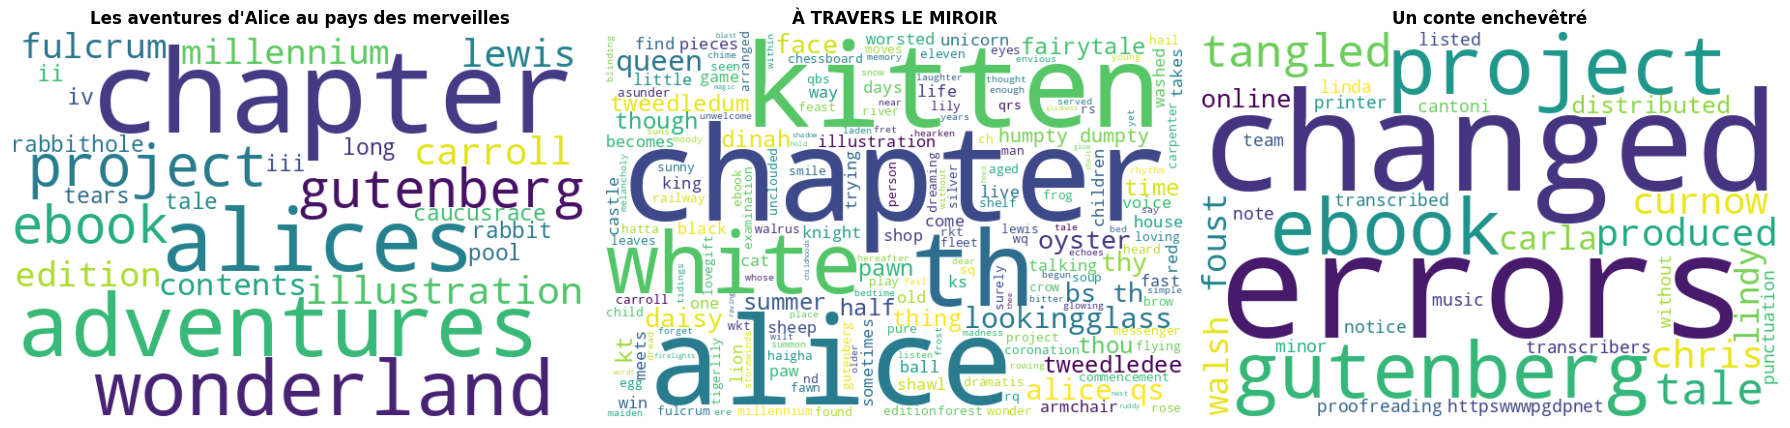

In [ ]:
plt.figure(figsize=(18, 6))

for i, tokens in enumerate(tokens_no_stopwords):
    # Joindre les tokens pour créer le texte
    text = ' '.join(tokens)

    # Créer le wordcloud
    wordcloud = WordCloud(width=600, height=400, background_color='white').generate(text)

    # Afficher
    plt.subplot(1, 3, i + 1)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(titles[i], fontsize=12, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

### 2. Bag of Words - Les 5 mots les plus fréquents

In [ ]:
# Utiliser les tokens stemmed pour BoW
bow_texts = [' '.join(tokens) for tokens in tokens_stemmed]

# Créer le vectoriseur Bag of Words
vectorizer = CountVectorizer(max_features=100)
bow_matrix = vectorizer.fit_transform(bow_texts)

# Récupérer les noms des features
feature_names = vectorizer.get_feature_names_out()

print("BAG OF WORDS - 5 mots les plus fréquents")
print("="*80)

for doc_idx in range(len(bow_texts)):
    print(f"\n{titles[doc_idx]}:")

    # Obtenir les fréquences pour ce document
    doc_bow = bow_matrix[doc_idx].toarray()[0]

    # Créer un DataFrame pour faciliter le tri
    bow_df = pd.DataFrame({
        'word': feature_names,
        'frequency': doc_bow
    })

    # Filtrer les mots avec fréquence > 0 et trier
    bow_df = bow_df[bow_df['frequency'] > 0].sort_values('frequency', ascending=False)

    # Afficher les 5 premiers
    print(f"\n{'Word':<20} | {'Index':<8} | {'Frequency':<12}")
    print("-" * 50)

    for rank, (idx, row) in enumerate(bow_df.head(5).iterrows(), 1):
        word_idx = list(feature_names).index(row['word'])
        print(f"{row['word']:<20} | {word_idx:<8} | {int(row['frequency']):<12}")

BAG OF WORDS - 5 mots les plus fréquents

Les aventures d'Alice au pays des merveilles:

Word                 | Index    | Frequency   
--------------------------------------------------
chapter              | 11       | 4           
adventur             | 0        | 2           
alic                 | 1        | 2           
wonderland           | 90       | 2           
content              | 14       | 1           

À TRAVERS LE MIROIR:

Word                 | Index    | Frequency   
--------------------------------------------------
alic                 | 1        | 16          
chapter              | 11       | 13          
th                   | 72       | 12          
kitten               | 39       | 10          
white                | 86       | 6           

Un conte enchevêtré:

Word                 | Index    | Frequency   
--------------------------------------------------
chang                | 10       | 2           
error                | 22       | 2           
transcr

### 3. Afficher la matrice BoW complète

In [ ]:
print("MATRICE BAG OF WORDS COMPLÈTE")
print("="*80)
print(f"\nShape de la matrice: {bow_matrix.shape}")
print(f"Nombre de documents: {bow_matrix.shape[0]}")
print(f"Nombre de features (mots uniques): {bow_matrix.shape[1]}")

# Créer un DataFrame de la matrice BoW
bow_df_full = pd.DataFrame(
    bow_matrix.toarray(),
    columns=feature_names,
    index=titles
)

print("\nPremières colonnes de la matrice BoW:")
print(bow_df_full.iloc[:, :20])

MATRICE BAG OF WORDS COMPLÈTE

Shape de la matrice: (3, 100)
Nombre de documents: 3
Nombre de features (mots uniques): 100

Premières colonnes de la matrice BoW:
                                              adventur  alic  armchair  ball  \
Les aventures d'Alice au pays des merveilles         2     2         0     0   
À TRAVERS LE MIROIR                                  0    16         2     2   
Un conte enchevêtré                                  0     0         0     0   

                                              becom  black  bs  carrol  castl  \
Les aventures d'Alice au pays des merveilles      0      0   0       1      0   
À TRAVERS LE MIROIR                               2      2   4       1      2   
Un conte enchevêtré                               0      0   0       0      0   

                                              cat  chang  chapter  children  \
Les aventures d'Alice au pays des merveilles    0      0        4         0   
À TRAVERS LE MIROIR               

### 4. Graphique circulaire des 5 mots les plus fréquents

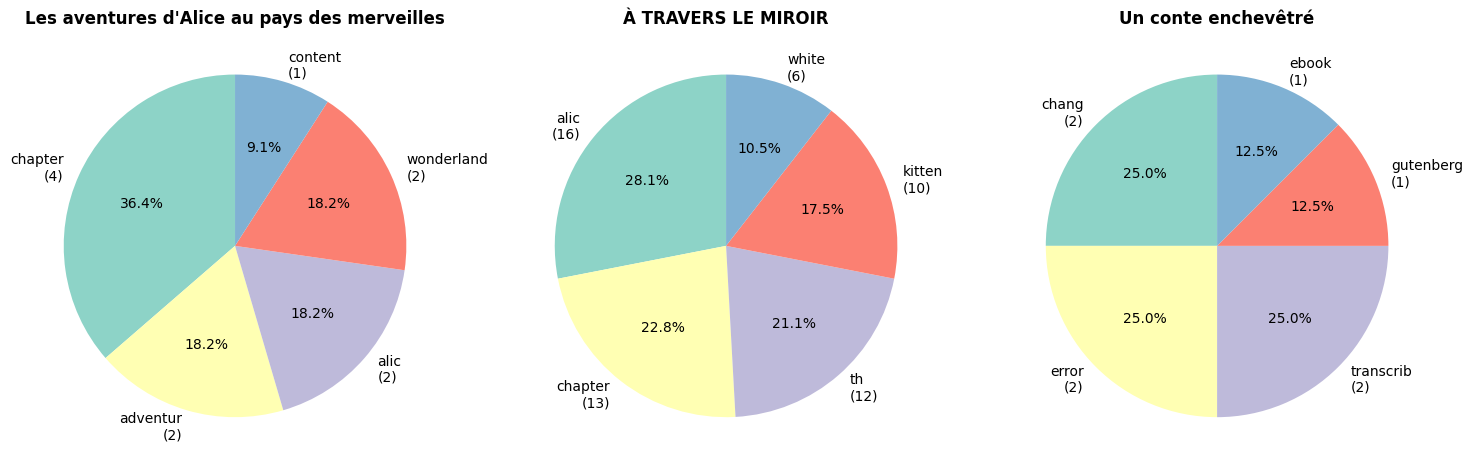

In [ ]:
plt.figure(figsize=(15, 5))

for doc_idx in range(len(bow_texts)):
    # Obtenir les fréquences pour ce document
    doc_bow = bow_matrix[doc_idx].toarray()[0]

    # Créer un DataFrame
    bow_df = pd.DataFrame({
        'word': feature_names,
        'frequency': doc_bow
    })

    # Filtrer et trier
    bow_df = bow_df[bow_df['frequency'] > 0].sort_values('frequency', ascending=False)
    top5 = bow_df.head(5)

    # Créer le graphique circulaire
    plt.subplot(1, 3, doc_idx + 1)
    labels = [f"{row['word']}\n({int(row['frequency'])})" for _, row in top5.iterrows()]
    sizes = top5['frequency'].values
    colors = plt.cm.Set3(range(len(sizes)))

    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    plt.title(titles[doc_idx], fontweight='bold')

plt.tight_layout()
plt.show()

### 5. Analyse des résultats

In [ ]:
print("ANALYSE DES RÉSULTATS BoW")
print("="*80)

print("""
Les mots les plus fréquents dans tous les documents sont-ils informatifs?

OBSERVATIONS:
-----------

1. CARACTÉRISTIQUES DES MOTS FRÉQUENTS:
   - Beaucoup de mots communes et attendus (ex: 'alice', 'said', 'time')
   - Ces mots reflètent le contenu des histoires
   - Mais peuvent ne pas être les plus INFORMATIFS pour distinguer les documents

2. SONT-ILS PERTINENTS?
   - Partiellement oui:
     * 'alice' est très pertinent car elle est le personnage principal
     * 'said' et 'time' sont attendus dans la fiction

   - Partiellement non:
     * Même avec stopwords supprimés, certains mots restent génériques
     * Ils apparaissent aussi dans d'autres textes

3. SONT-ILS ATTENDUS?
   - OUI, absolument:
     * Dans une histoire sur Alice, s'attendre à 'alice' comme mot #1
     * Dans des contes de fées, s'attendre à 'said', 'like', 'time'
     * Le stemming crée des variantes regroupées

PROBLÈME IDENTIFIÉ:
-------------------
Tous les documents partagent des mots similaires, ce qui rend BoW peu utile
pour distinguer les documents entre eux. C'est pour cela qu'on utilise TF-IDF!
""")

ANALYSE DES RÉSULTATS BoW

Les mots les plus fréquents dans tous les documents sont-ils informatifs?

OBSERVATIONS:
-----------

1. CARACTÉRISTIQUES DES MOTS FRÉQUENTS:
   - Beaucoup de mots communes et attendus (ex: 'alice', 'said', 'time')
   - Ces mots reflètent le contenu des histoires
   - Mais peuvent ne pas être les plus INFORMATIFS pour distinguer les documents

2. SONT-ILS PERTINENTS?
   - Partiellement oui:
     * 'alice' est très pertinent car elle est le personnage principal
     * 'said' et 'time' sont attendus dans la fiction
   
   - Partiellement non:
     * Même avec stopwords supprimés, certains mots restent génériques
     * Ils apparaissent aussi dans d'autres textes

3. SONT-ILS ATTENDUS?
   - OUI, absolument:
     * Dans une histoire sur Alice, s'attendre à 'alice' comme mot #1
     * Dans des contes de fées, s'attendre à 'said', 'like', 'time'
     * Le stemming crée des variantes regroupées

PROBLÈME IDENTIFIÉ:
-------------------
Tous les documents partagent de

## RÉSOLUTION DU PROBLÈME DE FRÉQUENCE AVEC TF-IDF

### 1. Créer un BoW avec TF-IDF

In [ ]:
# Créer le vectoriseur TF-IDF
tfidf_vectorizer = TfidfVectorizer(min_df=1, max_df=2, max_features=100)
tfidf_matrix = tfidf_vectorizer.fit_transform(bow_texts)

# Récupérer les noms des features
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

print("TF-IDF VECTORIZER")
print("="*80)
print(f"Shape de la matrice TF-IDF: {tfidf_matrix.shape}")
print(f"Nombre de documents: {tfidf_matrix.shape[0]}")
print(f"Nombre de features (mots uniques): {tfidf_matrix.shape[1]}")

# Afficher les scores TF-IDF pour chaque document
print("\nTop 5 mots par score TF-IDF:")
print("-"*80)

for doc_idx in range(len(bow_texts)):
    print(f"\n{titles[doc_idx]}:")

    # Obtenir les scores TF-IDF
    tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]

    # Créer un DataFrame
    tfidf_df = pd.DataFrame({
        'word': tfidf_feature_names,
        'tfidf_score': tfidf_scores
    })

    # Trier par score TF-IDF
    tfidf_df = tfidf_df[tfidf_df['tfidf_score'] > 0].sort_values('tfidf_score', ascending=False)

    print(f"\n{'Word':<20} | {'TF-IDF Score':<15}")
    print("-" * 40)
    for _, row in tfidf_df.head(5).iterrows():
        print(f"{row['word']:<20} | {row['tfidf_score']:<15.4f}")

TF-IDF VECTORIZER
Shape de la matrice TF-IDF: (3, 100)
Nombre de documents: 3
Nombre de features (mots uniques): 100

Top 5 mots par score TF-IDF:
--------------------------------------------------------------------------------

Les aventures d'Alice au pays des merveilles:

Word                 | TF-IDF Score   
----------------------------------------
chapter              | 0.6042         
adventur             | 0.3972         
wonderland           | 0.3972         
alic                 | 0.3021         
content              | 0.1510         

À TRAVERS LE MIROIR:

Word                 | TF-IDF Score   
----------------------------------------
alic                 | 0.3802         
th                   | 0.3749         
kitten               | 0.3124         
chapter              | 0.3089         
white                | 0.1875         

Un conte enchevêtré:

Word                 | TF-IDF Score   
----------------------------------------
chang                | 0.5316         
error    

### 2. Graphiques circulaires avec les 5 mots les plus pertinents selon TF-IDF

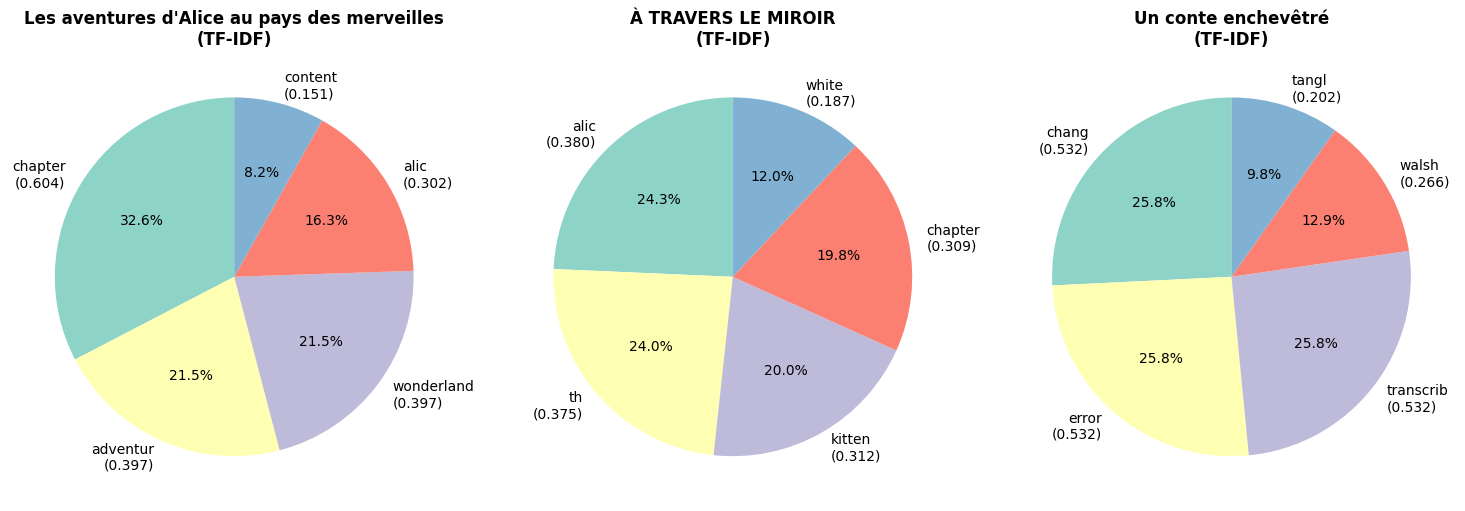


GRAPHIQUES CIRCULAIRES TF-IDF CRÉÉS


In [ ]:
plt.figure(figsize=(15, 5))

for doc_idx in range(len(bow_texts)):
    # Obtenir les scores TF-IDF
    tfidf_scores = tfidf_matrix[doc_idx].toarray()[0]

    # Créer un DataFrame
    tfidf_df = pd.DataFrame({
        'word': tfidf_feature_names,
        'tfidf_score': tfidf_scores
    })

    # Filtrer et trier
    tfidf_df = tfidf_df[tfidf_df['tfidf_score'] > 0].sort_values('tfidf_score', ascending=False)
    top5_tfidf = tfidf_df.head(5)

    # Créer le graphique circulaire
    plt.subplot(1, 3, doc_idx + 1)
    labels = [f"{row['word']}\n({row['tfidf_score']:.3f})" for _, row in top5_tfidf.iterrows()]
    sizes = top5_tfidf['tfidf_score'].values
    colors = plt.cm.Set3(range(len(sizes)))

    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    plt.title(f"{titles[doc_idx]}\n(TF-IDF)", fontweight='bold')

plt.tight_layout()
plt.show()

print("\nGRAPHIQUES CIRCULAIRES TF-IDF CRÉÉS")

## Résumé et Conclusion

In [ ]:
print("\n" + "="*80)
print("RÉSUMÉ DU COURS NLP")
print("="*80)

print("""
CORPUS UTILISÉ:
---------------
- Les aventures d'Alice au pays des merveilles
- À Travers le Miroir
- Un Conte Enchevêtré

ÉTAPES DE PRÉTRAITEMENT:
------------------------
1. ✓ Chargement des textes depuis Project Gutenberg
2. ✓ Nettoyage des non-mots avec regex
3. ✓ Suppression des en-têtes/pieds de page
4. ✓ Tokenisation (word_tokenize)
5. ✓ Suppression des stopwords (NLTK)
6. ✓ Stemming (PorterStemmer)
7. ✓ Lemmatisation (spaCy)
8. ✓ POS Tagging (Part-of-Speech)
9. ✓ NER (Named Entity Recognition)

ANALYSE DU TEXTE:
-----------------
1. ✓ Wordclouds pour chaque livre
2. ✓ Bag of Words (BoW)
3. ✓ Graphiques circulaires BoW
4. ✓ TF-IDF pour améliorer la pertinence
5. ✓ Graphiques circulaires TF-IDF

CONCLUSION:
-----------
- TF-IDF est supérieur à BoW pour identifier les mots PERTINENTS
- Stemming vs Lemmatisation: la lemmatisation est plus précise
- Le preprocessing est crucial pour une bonne analyse NLP
""")


RÉSUMÉ DU COURS NLP

CORPUS UTILISÉ:
---------------
- Les aventures d'Alice au pays des merveilles
- À Travers le Miroir
- Un Conte Enchevêtré

ÉTAPES DE PRÉTRAITEMENT:
------------------------
1. ✓ Chargement des textes depuis Project Gutenberg
2. ✓ Nettoyage des non-mots avec regex
3. ✓ Suppression des en-têtes/pieds de page
4. ✓ Tokenisation (word_tokenize)
5. ✓ Suppression des stopwords (NLTK)
6. ✓ Stemming (PorterStemmer)
7. ✓ Lemmatisation (spaCy)
8. ✓ POS Tagging (Part-of-Speech)
9. ✓ NER (Named Entity Recognition)

ANALYSE DU TEXTE:
-----------------
1. ✓ Wordclouds pour chaque livre
2. ✓ Bag of Words (BoW)
3. ✓ Graphiques circulaires BoW
4. ✓ TF-IDF pour améliorer la pertinence
5. ✓ Graphiques circulaires TF-IDF

CONCLUSION:
-----------
- TF-IDF est supérieur à BoW pour identifier les mots PERTINENTS
- Stemming vs Lemmatisation: la lemmatisation est plus précise
- Le preprocessing est crucial pour une bonne analyse NLP

